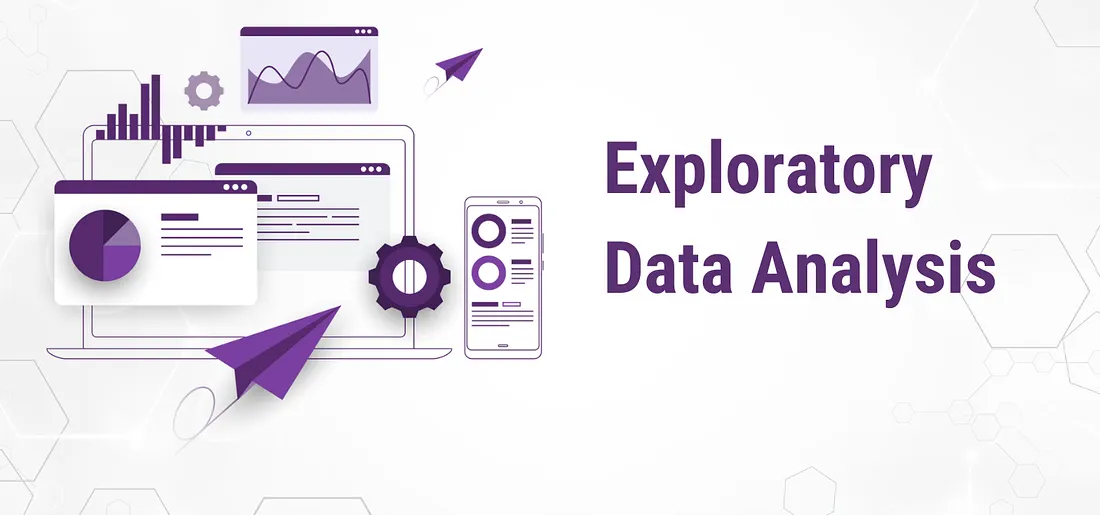

# 03. Exploratory Data Analysis Report

## Problem Statement

After data cleaning, the business needs to understand how Meghana Foods branches are performing across revenue, orders, complaints, ratings, customer loyalty, delivery performance, and branch health.

Raw numbers alone do not help business owners make decisions. Therefore, this notebook performs Exploratory Data Analysis to convert cleaned branch data into meaningful business insights.

---

## Business Objective

The objective of this notebook is to understand the current business performance of Meghana Foods branches.

This analysis helps answer:

- Which branch generates the highest revenue?
- Which branch receives the most orders?
- Which branch has the highest complaints?
- Which branch has the best customer rating?
- Which branch has strong repeat customers?
- Which months generate higher revenue?
- Does delivery delay increase complaints?
- Do better ratings support higher revenue?
- Which branch groups are healthy, stable, or at risk?

---

## Project Lifecycle Position

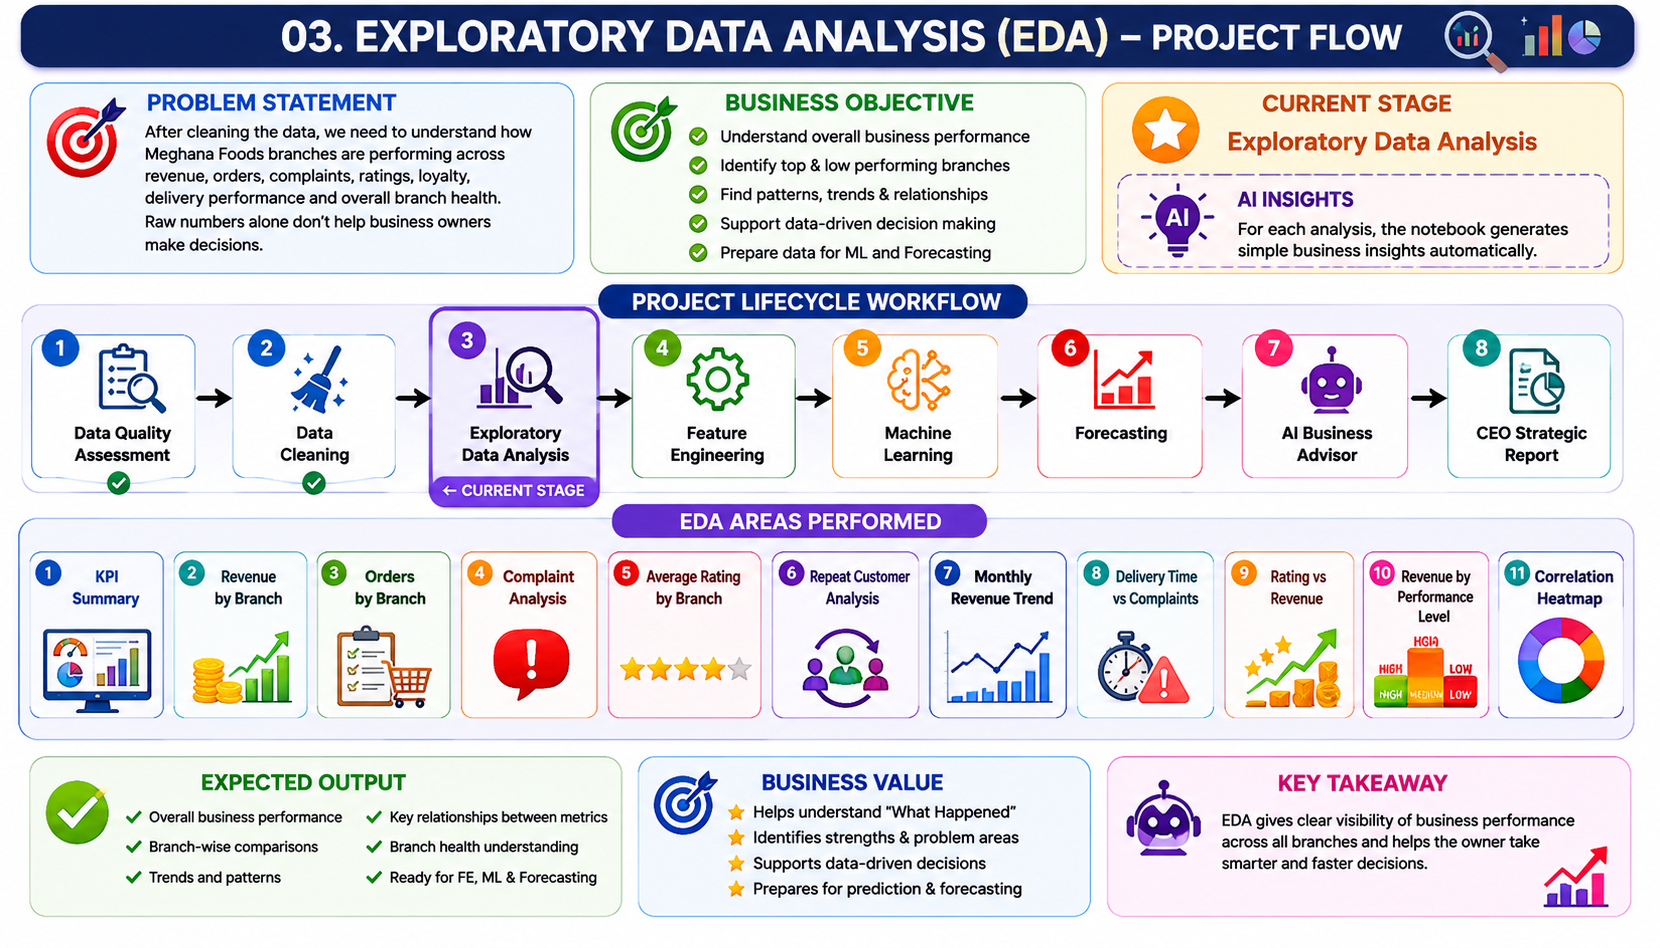

Current Stage:

Exploratory Data Analysis

Workflow:

1. Data Quality Assessment
2. Data Cleaning
3. Exploratory Data Analysis ← Current Stage
4. Feature Engineering
5. Machine Learning
6. Forecasting
7. AI Business Advisor
8. CEO Strategic Report

---

## Dataset Used

This notebook uses the cleaned branch performance dataset generated after the automated data cleaning process.

Each record represents the monthly performance of one Meghana Foods branch.

---

## EDA Sections Performed

### 1. KPI Summary

Shows overall business performance using:

- Total Revenue
- Total Orders
- Average Rating
- Total Customers
- Total Complaints

Purpose:

To give the owner a quick high-level view of the business.

---

### 2. Revenue by Branch

Compares total revenue generated by each branch.

Purpose:

To identify top revenue-generating branches and low revenue branches.

---

### 3. Orders by Branch

Compares total order volume across branches.

Purpose:

To understand customer demand branch-wise.

---

### 4. Complaint Analysis

Compares complaint volume across branches.

Purpose:

To identify branches with operational or customer satisfaction issues.

---

### 5. Average Rating by Branch

Compares average customer ratings across branches.

Purpose:

To understand customer satisfaction and branch reputation.

---

### 6. Repeat Customer Analysis

Compares repeat customers across branches.

Purpose:

To identify branches with strong customer loyalty.

---

### 7. Monthly Revenue Trend

Analyzes revenue movement over time.

Purpose:

To identify seasonal trends and high-demand months.

---

### 8. Delivery Time vs Complaints

Checks whether delivery delays are linked with higher complaints.

Purpose:

To understand operational impact on customer dissatisfaction.

---

### 9. Rating vs Revenue

Checks whether higher customer ratings are related to higher revenue.

Purpose:

To understand whether customer experience supports business growth.

---

### 10. Revenue by Performance Level

Compares revenue contribution from High, Medium, and Low performing branches.

Purpose:

To understand how much each performance segment contributes to overall revenue.

---

### 11. Branch Status Distribution

Shows the proportion of Healthy, Stable, and At Risk branches.

Purpose:

To understand overall business health.

---

### 12. Correlation Analysis

Shows relationships between numeric business metrics.

Purpose:

To identify which variables move together and which features may be useful for machine learning.

---

## AI Insight Layer

For each EDA section, the notebook generates simple business insights automatically.

These insights explain:

- What the chart means
- Why it matters
- What the owner should observe
- Which areas need attention

Note:

This is a basic rule-based AI insight layer. A more advanced AI Business Advisor will be built later after machine learning and forecasting.

---

## Expected Output

At the end of this notebook, we should clearly understand:

- Overall business performance
- Top and bottom branches
- Revenue trends
- Complaint patterns
- Rating patterns
- Customer loyalty trends
- Operational issues
- Branch health distribution
- Important business relationships

---

## Business Value

This EDA helps the owner understand what is happening in the business before moving into prediction and forecasting.

EDA answers:

“What happened?”

Later models will answer:

“What may happen next?”

The AI Business Advisor will answer:

“What should the owner do next?”

# Step 1 :  EDA (Exploratory Data Analysis)  


# Importing Libraries 

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Loading The file

In [7]:
df = pd.read_csv(r"D:\Skills Questions\End To End Projects\AI-Based Business Health & Revenue Forecasting Platform\1_Data\Processed Data\Meghana_Branch_Performance_Cleaned.csv")

df.head()

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min,Performance_Level,Branch_Status,Reason
0,K_01,Koramangala,South,2024-01-01,14788,6122232,4.6,11733,8447,3286,42,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
1,K_02,Koramangala,South,2024-02-01,14919,5505111,4.7,11248,7761,3487,56,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
2,K_03,Koramangala,South,2024-03-01,13215,4770615,4.8,9529,6575,2954,67,21,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
3,K_04,Koramangala,South,2024-04-01,14904,5946696,4.6,11604,8238,3366,76,25,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
4,K_05,Koramangala,South,2024-05-01,12189,4912167,4.5,9686,7167,2519,85,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall"


# Data Exploration

In [8]:
print(df.shape)

df.info()

df.describe()

(312, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Branch_ID          312 non-null    object 
 1   Branch_Name        312 non-null    object 
 2   Region             312 non-null    object 
 3   Month              312 non-null    object 
 4   Orders             312 non-null    int64  
 5   Revenue            312 non-null    int64  
 6   Avg_Rating         312 non-null    float64
 7   Customer_Count     312 non-null    int64  
 8   Repeat_Customers   312 non-null    int64  
 9   New_Customers      312 non-null    int64  
 10  Complaints         312 non-null    int64  
 11  Delivery_Time_Min  312 non-null    int64  
 12  Performance_Level  312 non-null    object 
 13  Branch_Status      312 non-null    object 
 14  Reason             312 non-null    object 
dtypes: float64(1), int64(7), object(7)
memory usage: 36.7+ KB


,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min
count,312.000000,3.120000e+02,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,9970.426282,3.819159e+06,4.258654,8010.009615,4959.157051,3050.852564,124.067308,31.278846
std,3439.674917,1.399686e+06,0.330918,2803.244116,2474.971133,550.732891,60.096696,8.373273
min,4501.000000,1.558220e+06,3.700000,3329.000000,1484.000000,1724.000000,35.000000,18.000000
25%,6709.500000,2.655717e+06,3.900000,5501.000000,2385.250000,2637.750000,75.000000,24.000000
50%,9828.000000,3.617614e+06,4.300000,7750.000000,4592.000000,3012.000000,112.500000,31.000000
75%,12945.250000,4.916311e+06,4.600000,10364.250000,7374.250000,3439.250000,171.500000,38.000000
max,17230.000000,8.307202e+06,4.800000,14247.000000,10685.000000,4562.000000,257.000000,47.000000


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_ai_insight(title, insight_points):
    print("\n" + "="*80)
    print(f"AI BUSINESS INSIGHTS: {title}")
    print("="*80)
    for point in insight_points:
        print(f"✅ {point}")
    print("="*80 + "\n")


def perform_eda(df):
    eda_results = {}

    # Convert Month safely
    df["Month"] = pd.to_datetime(df["Month"], errors="coerce")

    print("EDA STARTED...")
    print("Dataset Shape:", df.shape)

    # 1. KPI Summary
    total_revenue = df["Revenue"].sum()
    total_orders = df["Orders"].sum()
    avg_rating = round(df["Avg_Rating"].mean(), 2)
    total_customers = df["Customer_Count"].sum()
    total_complaints = df["Complaints"].sum()

    kpi_summary = pd.DataFrame({
        "Metric": [
            "Total Revenue",
            "Total Orders",
            "Average Rating",
            "Total Customers",
            "Total Complaints"
        ],
        "Value": [
            total_revenue,
            total_orders,
            avg_rating,
            total_customers,
            total_complaints
        ]
    })

    eda_results["kpi_summary"] = kpi_summary
    display(kpi_summary)

    generate_ai_insight("Overall Business Performance", [
        f"Total revenue generated is ₹{total_revenue:,.0f}.",
        f"Total orders received are {total_orders:,.0f}.",
        f"Average customer rating is {avg_rating}, which shows overall brand satisfaction.",
        f"Total complaints recorded are {total_complaints:,.0f}, which should be monitored branch-wise."
    ])

    # 2. Revenue by Branch
    branch_revenue = df.groupby("Branch_Name")["Revenue"].sum().sort_values(ascending=False)
    eda_results["branch_revenue"] = branch_revenue

    plt.figure(figsize=(12,6))
    branch_revenue.plot(kind="bar")
    plt.title("Total Revenue by Branch")
    plt.ylabel("Revenue")
    plt.xlabel("Branch")
    plt.xticks(rotation=45)
    plt.show()

    top_revenue_branch = branch_revenue.index[0]
    low_revenue_branch = branch_revenue.index[-1]

    generate_ai_insight("Branch Revenue Analysis", [
        f"{top_revenue_branch} is the highest revenue-generating branch.",
        f"{low_revenue_branch} is the lowest revenue-generating branch.",
        "High revenue branches should be studied to identify repeatable success patterns.",
        "Low revenue branches need deeper analysis on location, delivery delays, complaints, and customer retention."
    ])

    # 3. Orders by Branch
    branch_orders = df.groupby("Branch_Name")["Orders"].sum().sort_values(ascending=False)
    eda_results["branch_orders"] = branch_orders

    plt.figure(figsize=(12,6))
    branch_orders.plot(kind="bar")
    plt.title("Total Orders by Branch")
    plt.ylabel("Orders")
    plt.xlabel("Branch")
    plt.xticks(rotation=45)
    plt.show()

    generate_ai_insight("Order Volume Analysis", [
        f"{branch_orders.index[0]} has the highest order volume.",
        f"{branch_orders.index[-1]} has the lowest order volume.",
        "Order volume shows demand strength in each branch location.",
        "Branches with low order volume may need better marketing, offers, or delivery coverage."
    ])

    # 4. Complaint Analysis
    branch_complaints = df.groupby("Branch_Name")["Complaints"].sum().sort_values(ascending=False)
    eda_results["branch_complaints"] = branch_complaints

    plt.figure(figsize=(12,6))
    branch_complaints.plot(kind="bar")
    plt.title("Total Complaints by Branch")
    plt.ylabel("Complaints")
    plt.xlabel("Branch")
    plt.xticks(rotation=45)
    plt.show()

    generate_ai_insight("Complaint Analysis", [
        f"{branch_complaints.index[0]} has the highest complaints.",
        f"{branch_complaints.index[-1]} has the lowest complaints.",
        "High complaints may indicate issues in service, delivery time, packaging, or food consistency.",
        "Complaint-heavy branches should be prioritized for operational improvement."
    ])

    # 5. Average Rating by Branch
    branch_rating = df.groupby("Branch_Name")["Avg_Rating"].mean().sort_values(ascending=False)
    eda_results["branch_rating"] = branch_rating

    plt.figure(figsize=(12,6))
    branch_rating.plot(kind="bar")
    plt.title("Average Rating by Branch")
    plt.ylabel("Average Rating")
    plt.xlabel("Branch")
    plt.xticks(rotation=45)
    plt.show()

    generate_ai_insight("Customer Rating Analysis", [
        f"{branch_rating.index[0]} has the highest average rating.",
        f"{branch_rating.index[-1]} has the lowest average rating.",
        "Ratings reflect customer satisfaction and directly affect online ordering decisions.",
        "Low-rated branches should be checked for taste consistency, service quality, and delivery experience."
    ])

    # 6. Repeat Customer Analysis
    repeat_customers = df.groupby("Branch_Name")["Repeat_Customers"].sum().sort_values(ascending=False)
    eda_results["repeat_customers"] = repeat_customers

    plt.figure(figsize=(12,6))
    repeat_customers.plot(kind="bar")
    plt.title("Repeat Customers by Branch")
    plt.ylabel("Repeat Customers")
    plt.xlabel("Branch")
    plt.xticks(rotation=45)
    plt.show()

    generate_ai_insight("Customer Loyalty Analysis", [
        f"{repeat_customers.index[0]} has the highest repeat customers.",
        f"{repeat_customers.index[-1]} has the lowest repeat customers.",
        "Repeat customers are a strong sign of brand loyalty.",
        "Branches with low repeat customers need retention campaigns, offers, and service improvement."
    ])

    # 7. Monthly Revenue Trend
    monthly_revenue = df.groupby("Month")["Revenue"].sum()
    eda_results["monthly_revenue"] = monthly_revenue

    plt.figure(figsize=(14,5))
    monthly_revenue.plot(marker="o")
    plt.title("Monthly Revenue Trend")
    plt.ylabel("Revenue")
    plt.xlabel("Month")
    plt.xticks(rotation=45)
    plt.show()

    best_month = monthly_revenue.idxmax().strftime("%Y-%m")
    worst_month = monthly_revenue.idxmin().strftime("%Y-%m")

    generate_ai_insight("Monthly Revenue Trend", [
        f"Highest revenue was recorded in {best_month}.",
        f"Lowest revenue was recorded in {worst_month}.",
        "Revenue trend helps identify seasonal demand patterns.",
        "High-demand months can be used for campaigns, combos, and premium product promotions."
    ])

    # 8. Delivery Time vs Complaints
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x="Delivery_Time_Min", y="Complaints")
    plt.title("Delivery Time vs Complaints")
    plt.show()

    delivery_complaint_corr = round(df["Delivery_Time_Min"].corr(df["Complaints"]), 2)
    eda_results["delivery_complaint_corr"] = delivery_complaint_corr

    generate_ai_insight("Delivery Time Impact", [
        f"Correlation between delivery time and complaints is {delivery_complaint_corr}.",
        "If correlation is positive, longer delivery time is increasing complaints.",
        "Branches with high delivery time should improve dispatch speed and delivery partner coordination.",
        "Reducing delivery time can directly improve customer satisfaction."
    ])

    # 9. Rating vs Revenue
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x="Avg_Rating", y="Revenue")
    plt.title("Average Rating vs Revenue")
    plt.show()

    rating_revenue_corr = round(df["Avg_Rating"].corr(df["Revenue"]), 2)
    eda_results["rating_revenue_corr"] = rating_revenue_corr

    generate_ai_insight("Rating vs Revenue", [
        f"Correlation between rating and revenue is {rating_revenue_corr}.",
        "If correlation is positive, better ratings are supporting higher revenue.",
        "Customer experience improvement can increase both ratings and revenue.",
        "Low-rated branches should be improved before running aggressive marketing campaigns."
    ])

    # 10. Performance Level Revenue
    performance_revenue = df.groupby("Performance_Level")["Revenue"].sum().sort_values(ascending=False)
    eda_results["performance_revenue"] = performance_revenue

    plt.figure(figsize=(7,5))
    performance_revenue.plot(kind="bar")
    plt.title("Revenue by Performance Level")
    plt.ylabel("Revenue")
    plt.xlabel("Performance Level")
    plt.show()

    generate_ai_insight("Performance Level Analysis", [
        "High-performing branches contribute the strongest revenue share.",
        "Medium branches have growth potential and should be optimized.",
        "Low-performing branches need urgent attention on complaints, ratings, and delivery time.",
        "Performance segmentation helps owners prioritize branch-level action."
    ])

    # 11. Branch Status Distribution
    branch_status = df["Branch_Status"].value_counts()
    eda_results["branch_status"] = branch_status

    plt.figure(figsize=(6,6))
    branch_status.plot(kind="pie", autopct="%1.1f%%")
    plt.title("Branch Status Distribution")
    plt.ylabel("")
    plt.show()

    generate_ai_insight("Branch Health Status", [
        "Healthy branches are business strengths and can be used as benchmarks.",
        "Stable branches should be monitored for growth opportunities.",
        "At Risk branches require immediate investigation.",
        "This distribution helps owners focus management effort where it matters most."
    ])

    # 12. Correlation Heatmap
    numeric_df = df.select_dtypes(include=np.number)

    plt.figure(figsize=(12,8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

    eda_results["correlation_matrix"] = numeric_df.corr()

    generate_ai_insight("Correlation Analysis", [
        "Correlation helps understand which business metrics move together.",
        "Orders and revenue are expected to have strong positive relation.",
        "Delivery time and complaints should be monitored closely.",
        "Highly correlated features can later help in ML model building."
    ])

    print("EDA COMPLETED SUCCESSFULLY.")

    return eda_results

EDA STARTED...
Dataset Shape: (312, 15)


,Metric,Value
0,Total Revenue,1.191578e+09
1,Total Orders,3.110773e+06
2,Average Rating,4.260000e+00
3,Total Customers,2.499123e+06
4,Total Complaints,3.870900e+04



AI BUSINESS INSIGHTS: Overall Business Performance
✅ Total revenue generated is ₹1,191,577,548.
✅ Total orders received are 3,110,773.
✅ Average customer rating is 4.26, which shows overall brand satisfaction.
✅ Total complaints recorded are 38,709, which should be monitored branch-wise.



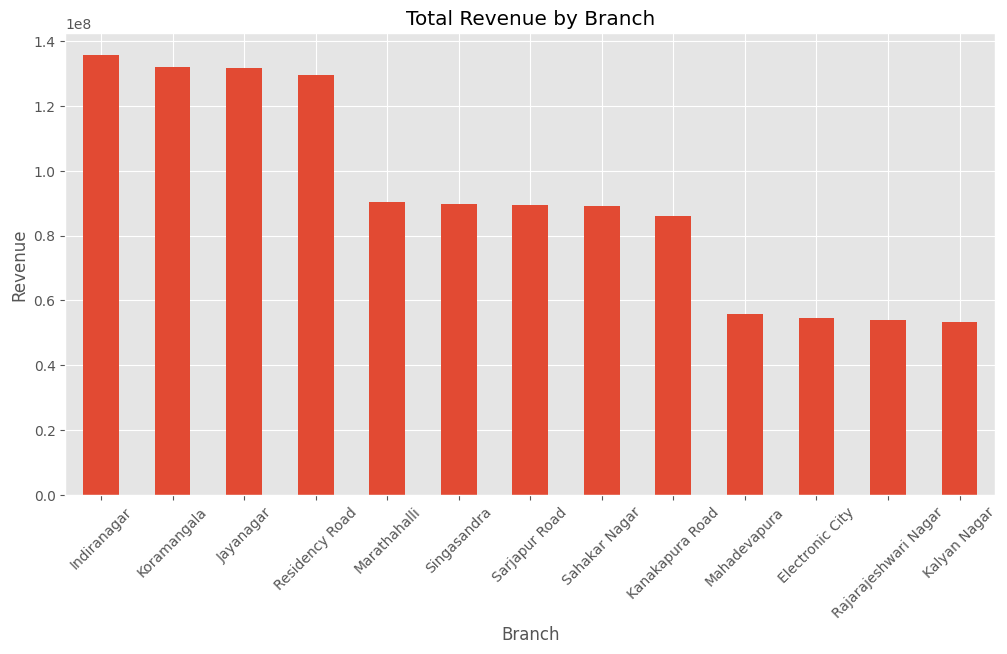


AI BUSINESS INSIGHTS: Branch Revenue Analysis
✅ Indiranagar is the highest revenue-generating branch.
✅ Kalyan Nagar is the lowest revenue-generating branch.
✅ High revenue branches should be studied to identify repeatable success patterns.
✅ Low revenue branches need deeper analysis on location, delivery delays, complaints, and customer retention.



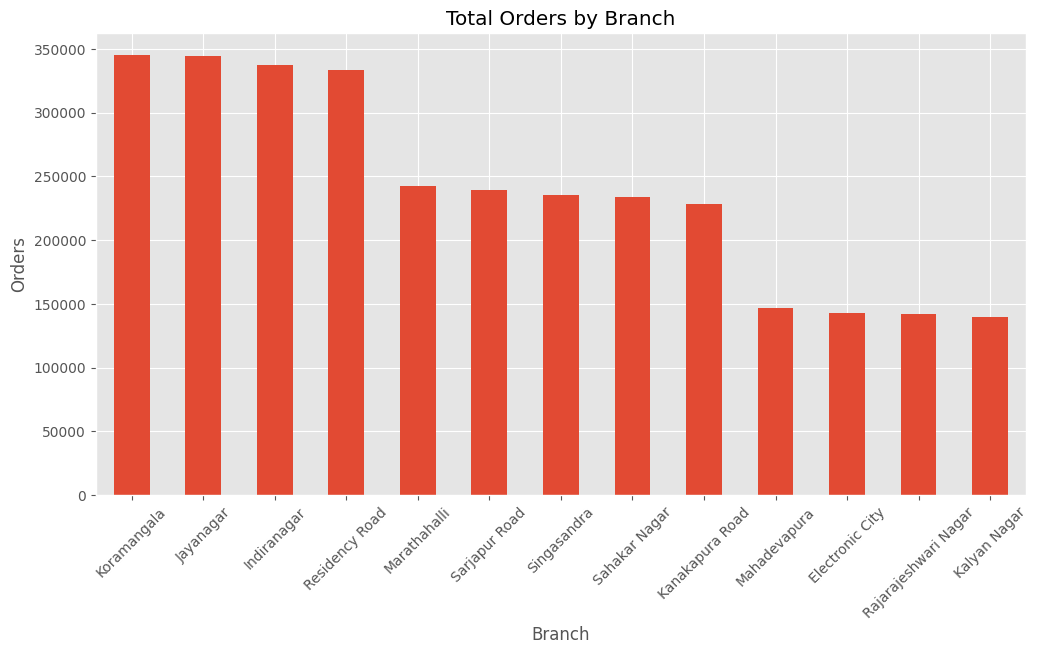


AI BUSINESS INSIGHTS: Order Volume Analysis
✅ Koramangala has the highest order volume.
✅ Kalyan Nagar has the lowest order volume.
✅ Order volume shows demand strength in each branch location.
✅ Branches with low order volume may need better marketing, offers, or delivery coverage.



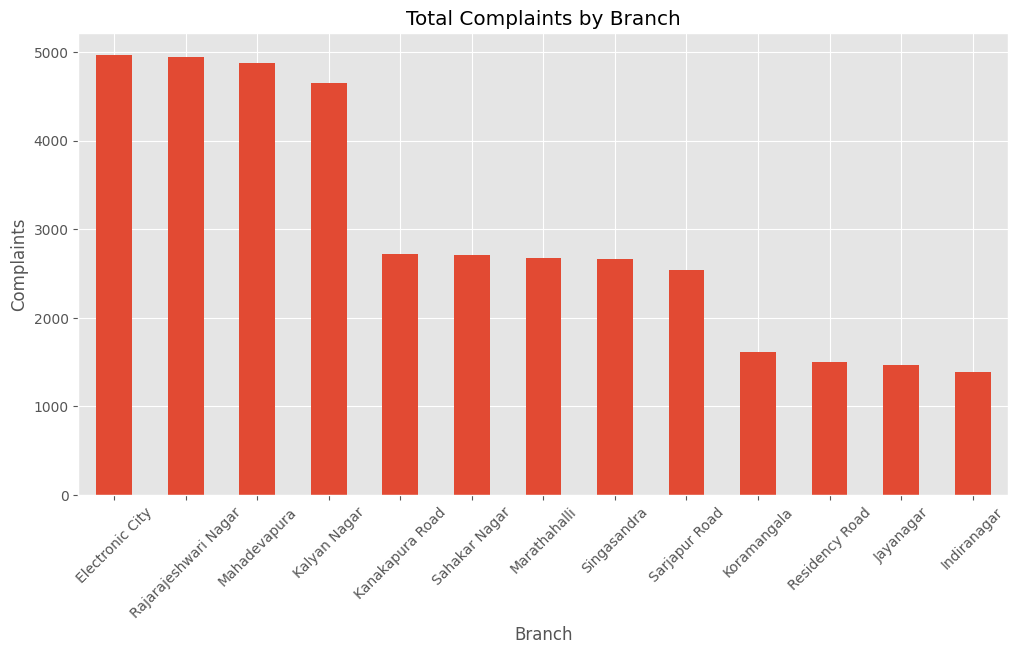


AI BUSINESS INSIGHTS: Complaint Analysis
✅ Electronic City has the highest complaints.
✅ Indiranagar has the lowest complaints.
✅ High complaints may indicate issues in service, delivery time, packaging, or food consistency.
✅ Complaint-heavy branches should be prioritized for operational improvement.



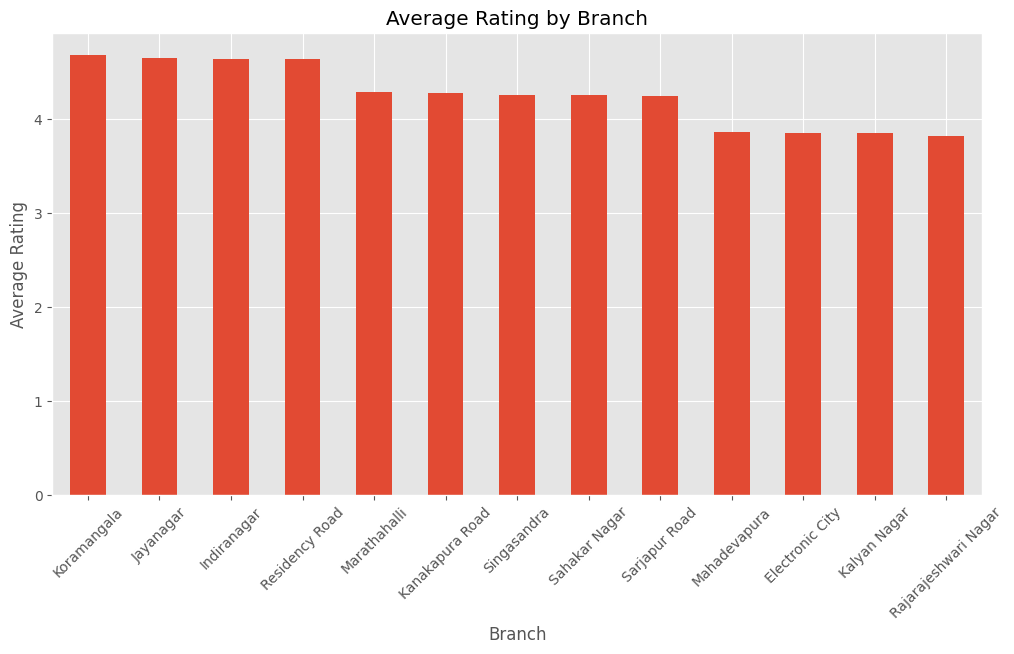


AI BUSINESS INSIGHTS: Customer Rating Analysis
✅ Koramangala has the highest average rating.
✅ Rajarajeshwari Nagar has the lowest average rating.
✅ Ratings reflect customer satisfaction and directly affect online ordering decisions.
✅ Low-rated branches should be checked for taste consistency, service quality, and delivery experience.



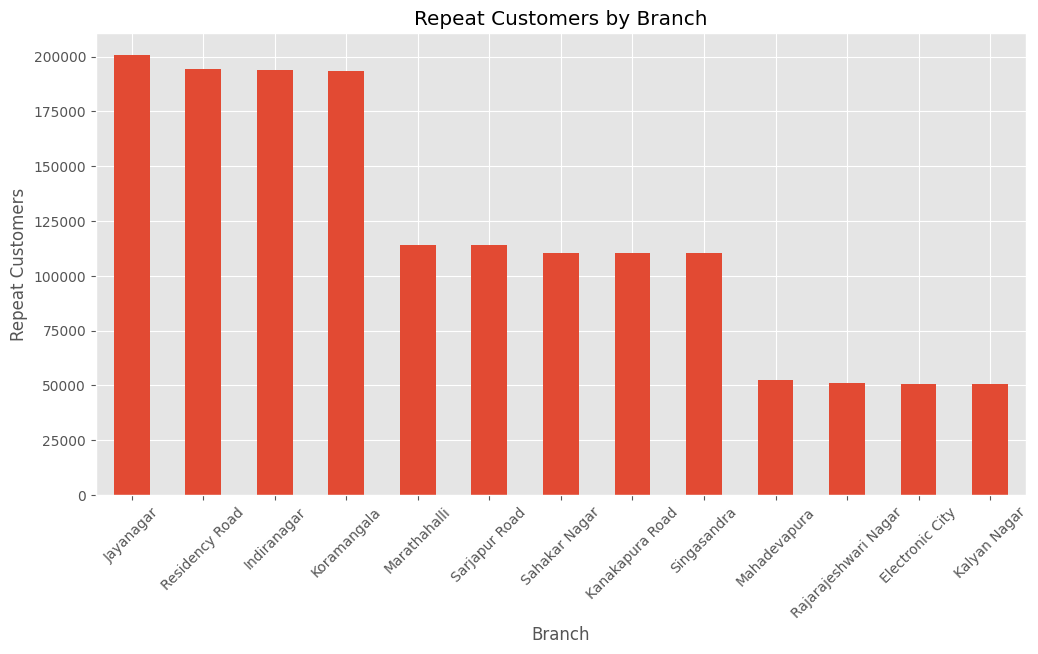


AI BUSINESS INSIGHTS: Customer Loyalty Analysis
✅ Jayanagar has the highest repeat customers.
✅ Kalyan Nagar has the lowest repeat customers.
✅ Repeat customers are a strong sign of brand loyalty.
✅ Branches with low repeat customers need retention campaigns, offers, and service improvement.



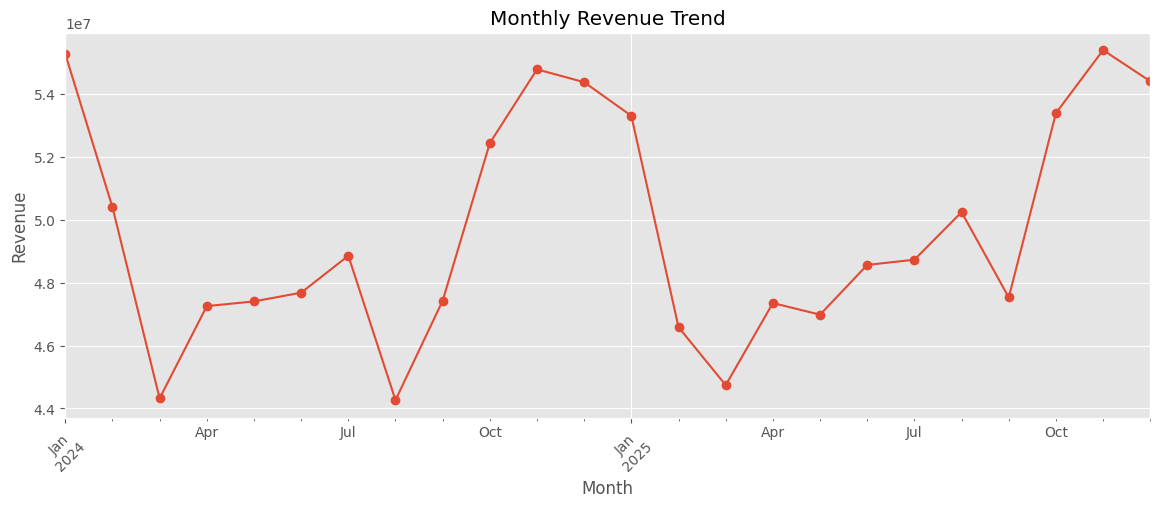


AI BUSINESS INSIGHTS: Monthly Revenue Trend
✅ Highest revenue was recorded in 2025-11.
✅ Lowest revenue was recorded in 2024-08.
✅ Revenue trend helps identify seasonal demand patterns.
✅ High-demand months can be used for campaigns, combos, and premium product promotions.



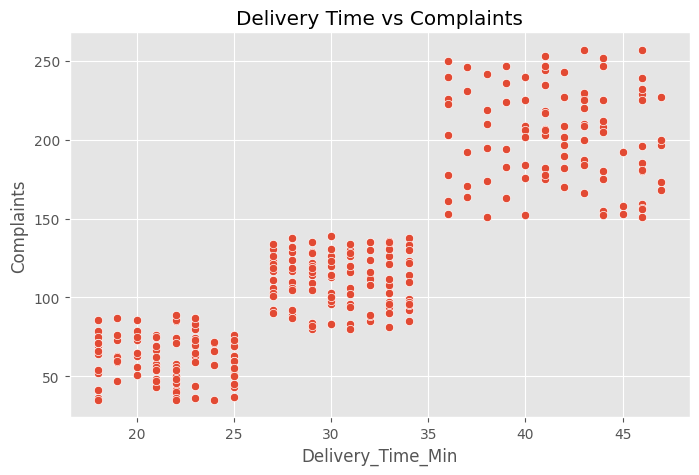


AI BUSINESS INSIGHTS: Delivery Time Impact
✅ Correlation between delivery time and complaints is 0.87.
✅ If correlation is positive, longer delivery time is increasing complaints.
✅ Branches with high delivery time should improve dispatch speed and delivery partner coordination.
✅ Reducing delivery time can directly improve customer satisfaction.



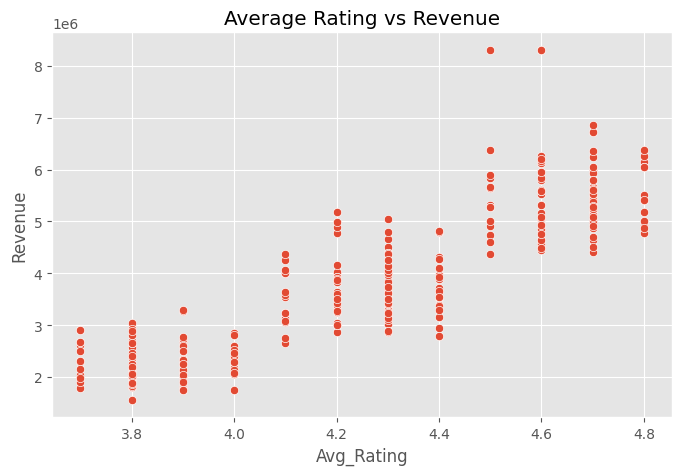


AI BUSINESS INSIGHTS: Rating vs Revenue
✅ Correlation between rating and revenue is 0.88.
✅ If correlation is positive, better ratings are supporting higher revenue.
✅ Customer experience improvement can increase both ratings and revenue.
✅ Low-rated branches should be improved before running aggressive marketing campaigns.



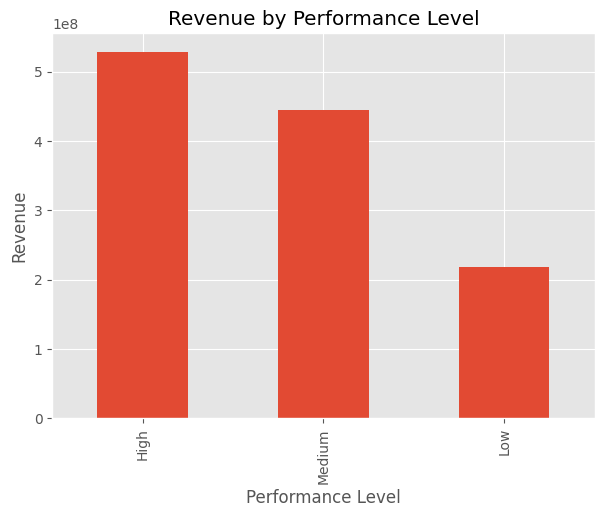


AI BUSINESS INSIGHTS: Performance Level Analysis
✅ High-performing branches contribute the strongest revenue share.
✅ Medium branches have growth potential and should be optimized.
✅ Low-performing branches need urgent attention on complaints, ratings, and delivery time.
✅ Performance segmentation helps owners prioritize branch-level action.



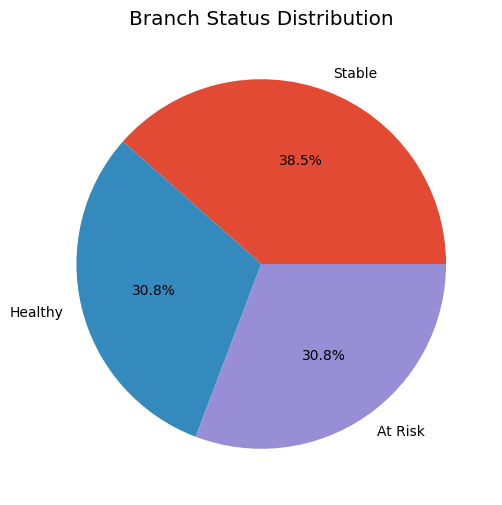


AI BUSINESS INSIGHTS: Branch Health Status
✅ Healthy branches are business strengths and can be used as benchmarks.
✅ Stable branches should be monitored for growth opportunities.
✅ At Risk branches require immediate investigation.
✅ This distribution helps owners focus management effort where it matters most.



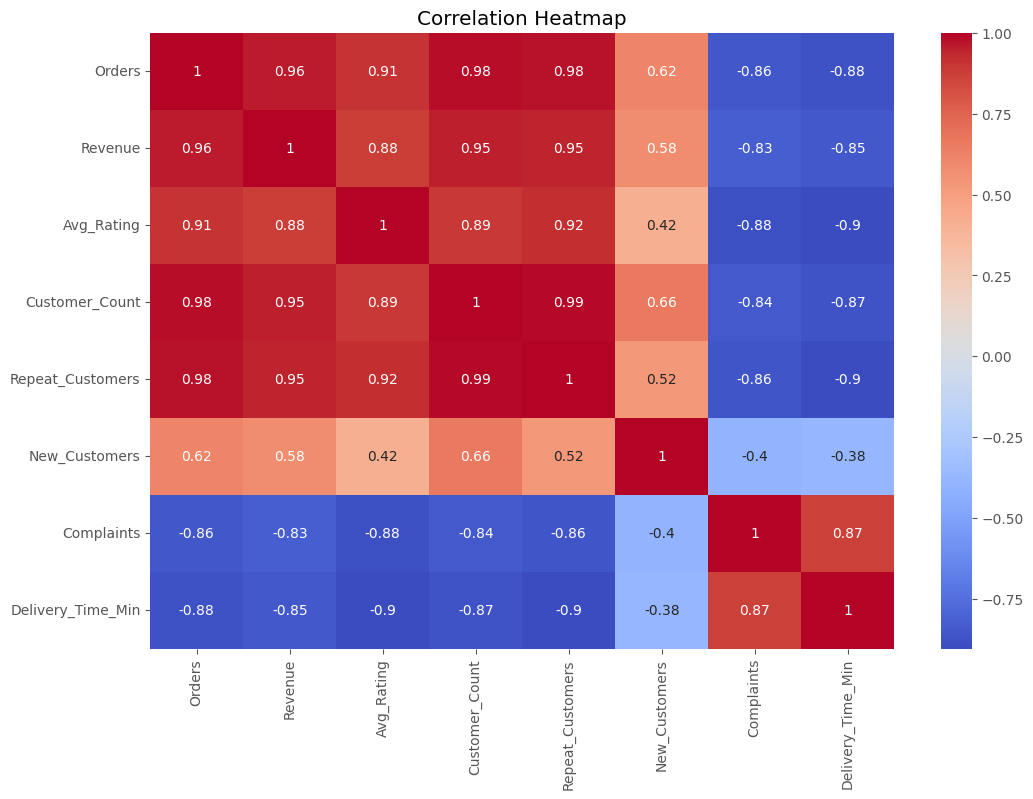


AI BUSINESS INSIGHTS: Correlation Analysis
✅ Correlation helps understand which business metrics move together.
✅ Orders and revenue are expected to have strong positive relation.
✅ Delivery time and complaints should be monitored closely.
✅ Highly correlated features can later help in ML model building.

EDA COMPLETED SUCCESSFULLY.


In [10]:
eda_results = perform_eda(df)